# Single Pulsar Fitting with JaxPINT

This notebook demonstrates how to use JaxPINT to fit a timing model to
pulsar TOA data. We use PSR NGC6440E, an isolated millisecond pulsar
in the globular cluster NGC 6440.

The workflow is:
1. Load the `.par` and `.tim` files using PINT
2. Convert to JaxPINT objects via the bridge layer
3. Run a Weighted Least Squares (WLS) fit
4. Inspect the results

## 1. Load data with PINT

JaxPINT uses PINT's data loading and model parsing infrastructure.
The `pint.config.examplefile` function resolves bundled example datasets
by name.

In [1]:
import pint.models as pm
import pint.toa as pt
from pint.config import examplefile

par_file = examplefile("NGC6440E.par")
tim_file = examplefile("NGC6440E.tim")

pint_model = pm.get_model(par_file)
pint_toas = pt.get_TOAs(tim_file, ephem="DE421")

print(f"Pulsar: {pint_model.PSR.value}")
print(f"Number of TOAs: {pint_toas.ntoas}")
print(f"MJD range: {pint_toas.get_mjds().min():.1f} – {pint_toas.get_mjds().max():.1f}")
print(f"\nFree parameters: {pint_model.free_params}")

2026-05-18 19:07:03.107 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2026-05-18 19:07:03.109 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2026-05-18 19:07:03.113 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2026-05-18 19:07:03.114 | DEBUG    | pint.observatory:_load_gps_clock:108 - Loading global GPS clock file
2026-05-18 19:07:03.120 | DEBUG    | pint.observatory.clock_file:__init__:812 - Global clock file gps2utc.clk saving kwargs={'bogus_last_correction': False, 'valid_beyond_ends': False}
2026-05-18 19:07:03.126 | DEBUG    | pint.observatory.clock_file:read_tempo2_clock_file:463 - Loading TEMPO2-format observatory clock correction file gps2utc.clk (/home/hector/.astropy/cache/download/url/d3c81b5766f4bfb84e65504c8a453085/contents) with bogus_last_correction=False
2026-05-18 19:07:03.153 | INFO     | pint.observatory:find_clock_file:

Pulsar: 1748-2021E
Number of TOAs: 62
MJD range: 53478.3 d – 54187.6 d

Free parameters: ['RAJ', 'DECJ', 'F0', 'F1', 'DM']


## 2. Convert to JaxPINT via the bridge layer

The bridge layer converts PINT objects into JaxPINT's JAX-native types:
- `pint_toas_to_jax` converts TOAs into a `TOAData` pytree of JAX arrays
- `pint_model_to_params` extracts the parameter values into a `ParameterVector`
- `build_timing_model` constructs the delay/phase/noise component chains

In [2]:
from jaxpint.bridge import (
    build_timing_model,
    pint_model_to_params,
    pint_toas_to_jax,
)

from jaxpint import ParameterVector

toa_data = pint_toas_to_jax(pint_toas, model=pint_model)
params = pint_model_to_params(pint_model).params
# Debugging
# idx_raj = params._name_to_index["RAJ"]                                                                                                                                                                                                                
# idx_decj = params._name_to_index["DECJ"]                                                                                                                                                                                                              
                                                                                                                                                                                                                                                    
# new_mask = list(params.frozen_mask)                                                                                                                                                                                                                   
# new_mask[idx_raj] = True
# new_mask[idx_decj] = True     

                
# params = ParameterVector(                                                                                                                                                                                                                
#     values=params.values,
#     frozen_mask=tuple(new_mask),                                                                                                                                                                                                                      
#     names=params.names,
#     units=params.units,
#     epoch_int_values=params.epoch_int_values,                                                                                                                                                                                                         
# )
# End debug
timing_model, noise_model = build_timing_model(pint_model, pint_toas)

print(f"Number of parameters: {len(params.names)}")
print(f"Free parameters: {params.n_free}")
print(f"Free parameter names: {params.free_names()}")

2026-05-18 19:07:07.457 | DEBUG    | pint.models.absolute_phase:get_TZR_toa:101 - Creating and dealing with the single TZR_toa for absolute phase
2026-05-18 19:07:07.461 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2026-05-18 19:07:07.462 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)


2026-05-18 19:07:07.465 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2026-05-18 19:07:07.466 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2023) clock correction (~27 us)
2026-05-18 19:07:07.469 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='gbt'.
2026-05-18 19:07:07.472 | DEBUG    | pint.toa:compute_TDBs:2278 - Computing TDB columns.
2026-05-18 19:07:07.473 | DEBUG    | pint.toa:compute_TDBs:2299 - Using EPHEM = DE421 for TDB calculation.
2026-05-18 19:07:07.476 | DEBUG    | pint.toa:compute_posvels:2379 - Computing PosVels of observatories and Earth, using DE421
2026-05-18 19:07:07.873 | INFO     | pint.solar_system_ephemerides:_load_kernel_link:85 - Set solar system ephemeris to de421 from download
2026-05-18 19:07:07.881 | DEBUG    | pint.toa:compute_posvels:2432 - SSB obs pos [-1.43853911e+11  3.19743359e+10  1.38482

Number of parameters: 15
Free parameters: 5
Free parameter names: ('RAJ', 'DECJ', 'F0', 'F1', 'DM')


## 3. Compute pre-fit residuals

Before fitting, let's look at the timing residuals. These are the
differences between observed and predicted pulse arrival times.

In [6]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxpint.fitters import compute_time_residuals
from jaxpint.fitters._base import _subtract_weighted_mean

pre_fit_resid = compute_time_residuals(timing_model, toa_data, params)
pre_fit_resid = _subtract_weighted_mean(pre_fit_resid, toa_data.error)

# Convert to microseconds for plotting
resid_us = pre_fit_resid * 1e6
err_us = toa_data.error * 1e6


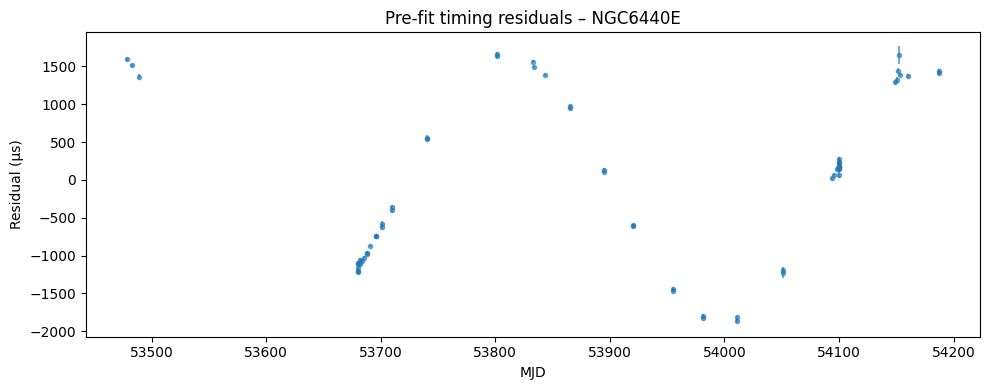

In [4]:
plt.figure(figsize=(10, 4))
plt.errorbar(toa_data.mjd.total, resid_us, yerr=err_us, fmt=".", alpha=0.6)
plt.xlabel("MJD")
plt.ylabel("Residual (μs)")
plt.title("Pre-fit timing residuals – NGC6440E")
plt.tight_layout()
plt.show()

## 4. Run the WLS fit

The `WLSFitter` uses Gauss-Newton iterations with the design matrix
computed via JAX autodiff. It returns a `WLSFitResult` containing
fitted parameters, covariance, chi-squared, and post-fit residuals.

In [ ]:
from jaxpint.fitters import WLSFitter

fitter = WLSFitter(timing_model, toa_data, params, noise_model=noise_model)
# JIT Warmup
result = fitter.fit_toas(maxiter=1)


In [6]:
result = fitter.fit_toas(maxiter=99)

In [7]:


print(f"Chi-squared: {result.chi2:.2f}")
print(f"Degrees of freedom: {result.dof}")
print(f"Reduced chi-squared: {result.reduced_chi2:.4f}")

Chi-squared: 59.57
Degrees of freedom: 57
Reduced chi-squared: 1.0452


## 5. Inspect fitted parameters

Compare the fitted parameter values and their uncertainties.

In [8]:
import numpy as np

free_names = result.params.free_names()
fitted_values = result.params.free_values()
uncertainties = result.parameter_uncertainties

print(f"{'Parameter':<20} {'Value':>20} {'Uncertainty':>15}")
print("-" * 55)
for name, val, err in zip(free_names, fitted_values, uncertainties):
    print(f"{name:<20} {float(val):>20.10g} {float(err):>15.4g}")

Parameter                           Value     Uncertainty
-------------------------------------------------------
RAJ                           4.663868852       6.119e-09
DECJ                        -0.3553169572        1.48e-07
F0                            61.48547655       1.718e-11
F1                       -1.181331748e-15       1.122e-18
DM                            224.1137949         0.03492


## 6. Plot post-fit residuals

After fitting, the residuals should be consistent with white noise
at the level of the TOA uncertainties.

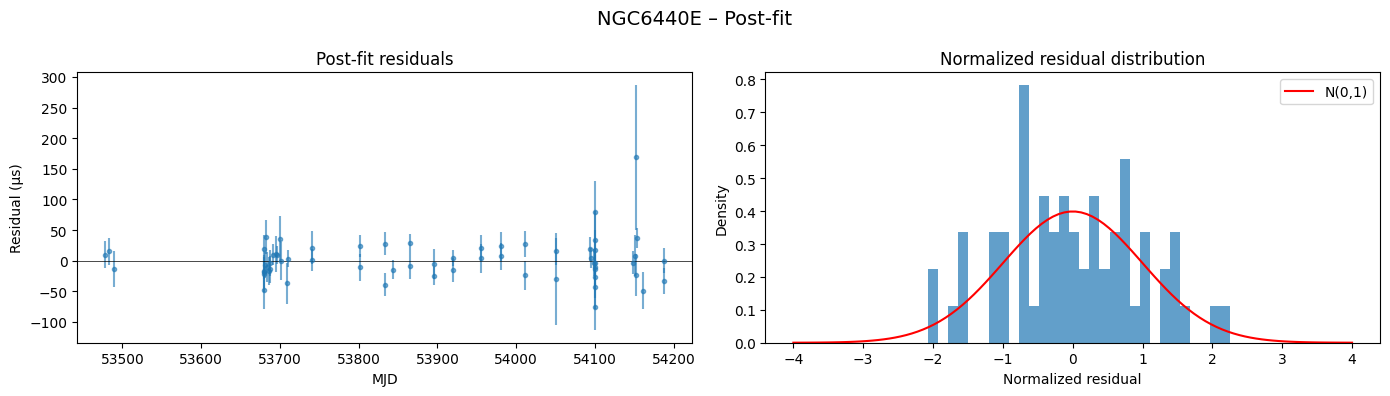

In [9]:
post_resid_us = result.residuals * 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Post-fit residuals vs MJD
axes[0].errorbar(toa_data.mjd.total, post_resid_us, yerr=err_us, fmt=".", alpha=0.6)
axes[0].axhline(0, color="k", linewidth=0.5)
axes[0].set_xlabel("MJD")
axes[0].set_ylabel("Residual (μs)")
axes[0].set_title("Post-fit residuals")

# Normalized residuals histogram
normalized = np.array(result.residuals / toa_data.error)
axes[1].hist(normalized, bins=30, density=True, alpha=0.7)
x = np.linspace(-4, 4, 100)
axes[1].plot(x, np.exp(-x**2 / 2) / np.sqrt(2 * np.pi), "r-", label="N(0,1)")
axes[1].set_xlabel("Normalized residual")
axes[1].set_ylabel("Density")
axes[1].set_title("Normalized residual distribution")
axes[1].legend()

fig.suptitle("NGC6440E – Post-fit", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Parameter correlation matrix

The correlation matrix shows which parameters are covariant.
Strong correlations (near ±1) indicate degeneracies.

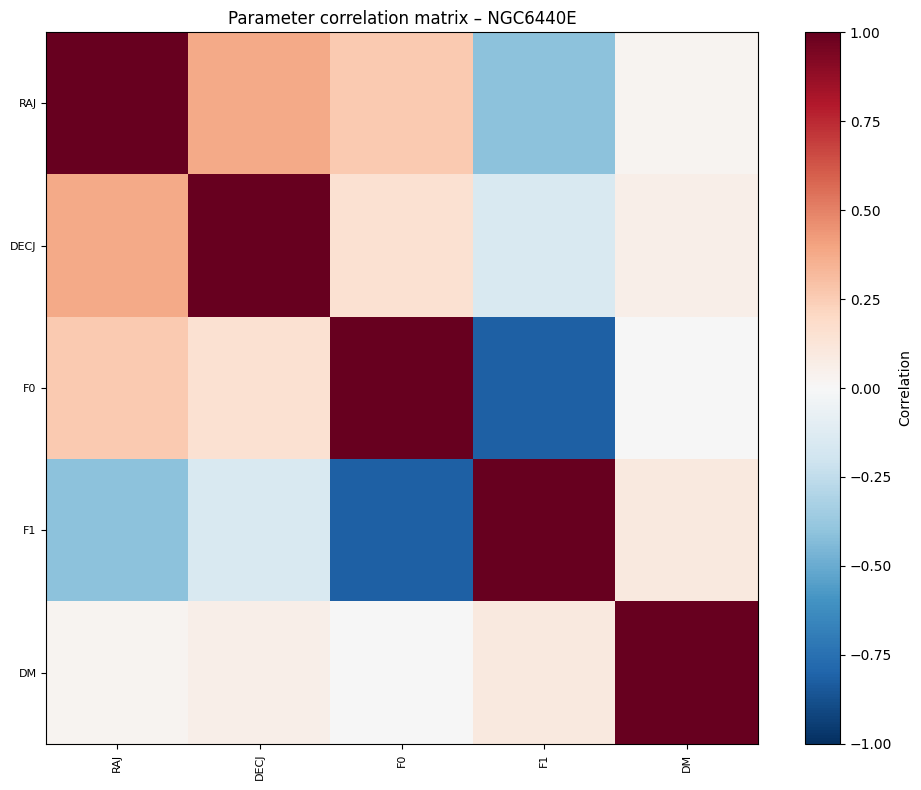

In [10]:
corr = np.array(result.correlation_matrix)

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(free_names)), free_names, rotation=90, fontsize=8)
plt.yticks(range(len(free_names)), free_names, fontsize=8)
plt.title("Parameter correlation matrix – NGC6440E")
plt.tight_layout()
plt.show()